# Exercise 8.6 — Q2: Spam Email Classification with SVM

**Lab Book §8.6 Exercise 2 (page 37):**  
> Using SVM, a company wants to classify emails as spam or not spam
> based on features such as word frequency and message length.

**Course:** 23CSE301 — Machine Learning Lab  
**Topic:** SVM Binary Classification on high-dimensional word-frequency data  
**Dataset:** `datasets/spambase.csv` (4 601 rows × 58 columns) — UCI Spambase.
The first 57 columns are word/character frequencies and capital-run-length
features; the last column `is_spam` (1 = spam, 0 = not spam) is the target.

---

## 🎯 Objective

Train an SVM classifier on the UCI Spambase dataset to predict whether an
email is spam.  Compare RBF and Linear kernels; report accuracy, precision,
recall, F1, and the confusion matrix.

## 📁 Files in this Folder

| File | Description |
|------|-------------|
| `04_Q2_Spam_Classification.ipynb` | This notebook |
| `datasets/spambase.csv`           | UCI Spambase (4 601 × 58) |
| `datasets/spambase.names`         | UCI Spambase documentation |


In [1]:
# === Environment setup (works in both Google Colab and local Jupyter) ===
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/ML-Lab-Activities-Complete'
    os.chdir(os.path.join(BASE, '04-SVM'))
    print(f'Running in Google Colab. CWD: {os.getcwd()}')
else:
    print(f'Running locally. CWD: {os.getcwd()}')

OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)
_PREFIX = 'Q2_Spam_'

# Patch plt.show so every figure is also auto-saved as PNG (with prefix to
# avoid collisions between multiple notebooks sharing the same outputs/ dir)
import matplotlib.pyplot as plt
_fig_counter = [0]
_orig_plt_show = plt.show
def _save_and_show(*args, **kwargs):
    for fnum in plt.get_fignums():
        _fig_counter[0] += 1
        fig = plt.figure(fnum)
        fname = f'{_PREFIX}figure_{_fig_counter[0]:03d}.png'
        try:
            fig.savefig(os.path.join(OUTPUT_DIR, fname), dpi=120, bbox_inches='tight')
        except Exception as e:
            print(f'Warning: could not save {fname}: {e}')
    _orig_plt_show(*args, **kwargs)
plt.show = _save_and_show

print('Setup complete. Figures will be auto-saved to:', OUTPUT_DIR)


Running locally. CWD: /home/z/my-project/work/build/ML-Lab-Activities/04-SVM


Setup complete. Figures will be auto-saved to: /home/z/my-project/work/build/ML-Lab-Activities/04-SVM/outputs


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             classification_report,
                             precision_score, recall_score, f1_score)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print('Libraries imported.')

Libraries imported.


## 2. Load Dataset

In [3]:
df = pd.read_csv('datasets/spambase.csv')
print(f"Shape: {df.shape}")
display(df.head())
print("\nClass distribution (0 = not spam, 1 = spam):")
print(df['is_spam'].value_counts())

Shape: (4601, 58)


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,is_spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1



Class distribution (0 = not spam, 1 = spam):
is_spam
0    2788
1    1813
Name: count, dtype: int64


## 3. Define Features & Target

In [4]:
y = df['is_spam']
X = df.drop(columns=['is_spam'])
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Number of features: {X.shape[1]}")

X shape: (4601, 57), y shape: (4601,)
Number of features: 57


## 4. Train/Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (3220, 57), Test: (1381, 57)


## 5. Standardise Features

In [6]:
sc = StandardScaler()
X_train_s = sc.fit_transform(X_train)
X_test_s  = sc.transform(X_test)
print("Features standardised.")

Features standardised.


## 6. Train SVM with Linear Kernel (fast on high-dim)

In [7]:
model = SVC(kernel='linear', random_state=0)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Spam', 'Spam']))

Accuracy  : 0.9290
Precision : 0.9160
Recall    : 0.9026
F1 Score  : 0.9093

Classification Report:
              precision    recall  f1-score   support

    Not Spam       0.94      0.95      0.94       837
        Spam       0.92      0.90      0.91       544

    accuracy                           0.93      1381
   macro avg       0.93      0.92      0.93      1381
weighted avg       0.93      0.93      0.93      1381



## 7. Confusion Matrix

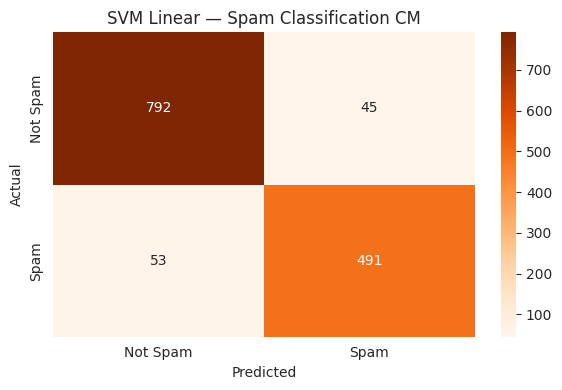

In [8]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Spam', 'Spam'],
            yticklabels=['Not Spam', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Linear — Spam Classification CM')
plt.tight_layout()
plt.show()

## 8. Compare Kernels

  linear    acc=0.9290  recall=0.9026  f1=0.9093


  rbf       acc=0.9276  recall=0.8879  f1=0.9062


  poly      acc=0.7705  recall=0.4412  f1=0.6023


,Kernel,Accuracy,Recall,F1
0,linear,0.929037,0.902574,0.909259
1,rbf,0.927589,0.887868,0.906191
2,poly,0.770456,0.441176,0.602258


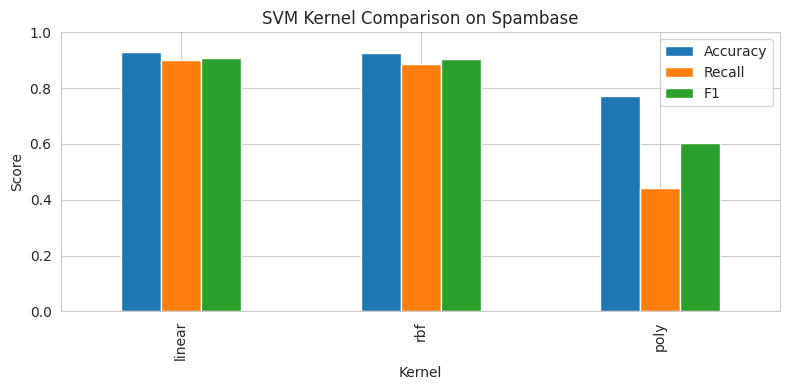

In [9]:
results = []
for kernel in ['linear', 'rbf', 'poly']:
    m = SVC(kernel=kernel, random_state=0)
    m.fit(X_train_s, y_train)
    yp = m.predict(X_test_s)
    a = accuracy_score(y_test, yp)
    r = recall_score(y_test, yp)
    f = f1_score(y_test, yp)
    results.append({'Kernel': kernel, 'Accuracy': a, 'Recall': r, 'F1': f})
    print(f"  {kernel:8s}  acc={a:.4f}  recall={r:.4f}  f1={f:.4f}")

cmp = pd.DataFrame(results)
display(cmp)

plt.figure(figsize=(8, 4))
cmp.set_index('Kernel')[['Accuracy','Recall','F1']].plot.bar(ax=plt.gca())
plt.ylim(0, 1); plt.ylabel('Score'); plt.title('SVM Kernel Comparison on Spambase')
plt.tight_layout(); plt.show()

## 📚 Key Takeaways
- **Spambase** is a high-dimensional dataset (57 features) — Linear SVM
  is often the best choice here because the data is sparse and linearly
  separable enough.
- **Precision** matters for spam filters — false positives (legit email
  marked as spam) are very costly.
- **RBF / Poly** kernels can sometimes squeeze out a bit more accuracy
  but at higher computational cost.
